# investalyze: fundamentals coverage (SimFin)

Maps what the SimFin fundamentals (`income`, `balance`, `cashflow`) can support before building
a point-in-time (PIT) join and ratios: universe overlap, publish-lag reliability, how much
restatements move key lines, and which columns are filled enough to use.

The `## Decisions` section at the end records what the PIT phase should assume.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
from helpers import connect_readonly, show_df, show_note

con = connect_readonly()

## 1. Coverage & universe overlap

### Rows and tickers per statement, period, restatement status

In [2]:
frames = []
for table in ['income', 'balance', 'cashflow']:
    df = con.execute(f'SELECT ? AS Statement, Period, IsRestated, count(*) AS Rows_, count(DISTINCT Ticker) AS Tickers'
                     f' FROM {table} GROUP BY ALL ORDER BY Period, IsRestated', [table]).df()
    frames.append(df)
show_df(pd.concat(frames, ignore_index=True))

,Statement,Period,IsRestated,Rows_,Tickers
0,income,A,False,"59,119","5,015"
1,income,A,True,"57,958","5,028"
2,income,Q,False,"165,941","4,818"
3,income,Q,True,"152,764","4,777"
4,balance,A,False,"59,118","5,015"
5,balance,A,True,"57,954","5,028"
6,balance,Q,False,"165,943","4,818"
7,balance,Q,True,"152,762","4,777"
8,cashflow,A,False,"59,119","5,015"
9,cashflow,A,True,"57,958","5,028"


### Tickers with all three statements vs any statement

In [3]:
show_df(con.execute("""
    SELECT
        (SELECT count(*) FROM (SELECT DISTINCT Ticker FROM income
                               INTERSECT SELECT DISTINCT Ticker FROM balance
                               INTERSECT SELECT DISTINCT Ticker FROM cashflow)) AS all_three,
        (SELECT count(*) FROM (SELECT DISTINCT Ticker FROM income
                               UNION SELECT DISTINCT Ticker FROM balance
                               UNION SELECT DISTINCT Ticker FROM cashflow)) AS any_statement
""").df())

,all_three,any_statement
0,"5,236","5,236"


### Ticker coverage by fiscal year, annual vs quarterly (original statements)

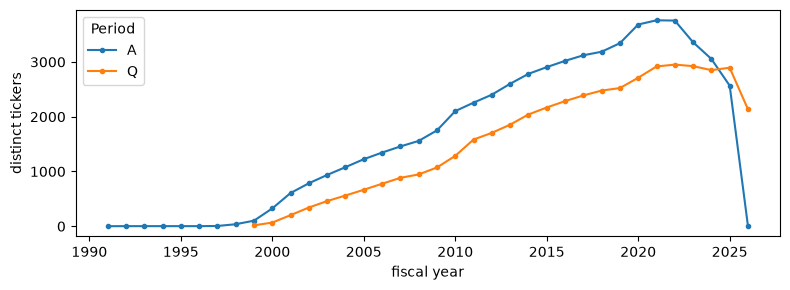

In [4]:
by_fy = con.execute("""
    SELECT "Fiscal Year" AS fy, Period, count(DISTINCT Ticker) AS Tickers
    FROM income
    WHERE IsRestated = false AND "Fiscal Year" BETWEEN 1990 AND 2026
    GROUP BY ALL ORDER BY fy, Period
""").df()
fig, ax = plt.subplots(figsize=(8, 3))
for period, group in by_fy.groupby('Period'):
    ax.plot(group['fy'], group['Tickers'], marker='.', label=period)
ax.set_xlabel('fiscal year')
ax.set_ylabel('distinct tickers')
ax.legend(title='Period')
plt.tight_layout()
plt.show()

### Overlap with the Yahoo price universe

In [5]:
show_df(con.execute("""
    WITH f AS (SELECT DISTINCT Ticker FROM income),
         p AS (SELECT DISTINCT Ticker FROM prices)
    SELECT
        (SELECT count(*) FROM f JOIN p USING (Ticker)) AS both_,
        (SELECT count(*) FROM p WHERE Ticker NOT IN (SELECT Ticker FROM f)) AS price_only,
        (SELECT count(*) FROM f WHERE Ticker NOT IN (SELECT Ticker FROM p)) AS fundamentals_only
""").df())

,both_,price_only,fundamentals_only
0,"3,091","5,130","2,145"


**Verdict:** every ticker with any statement has all three (no partial coverage). Annual
coverage ramps from a handful of tickers pre-1999 to a peak of about 3,700 around fiscal 2020-2021,
then tapers in the most recent year or two as an artifact of reporting lag (see chapter 2), not a
real data gap. Only 3,091 of the roughly 8,200 tickers spanning both universes have both price and
fundamentals data: most price-only tickers are presumably ETFs/funds/recent listings SimFin does
not cover, and the fundamentals-only tickers likely use different symbols or are delisted from the
Yahoo price universe, worth a ticker-mapping check as a follow-up.

## 2. Publish-lag & PIT viability

### Publish Date null rate per statement and period

In [6]:
frames = []
for table in ['income', 'balance', 'cashflow']:
    df = con.execute(f"""
        SELECT ? AS Statement, Period, count(*) AS Rows_,
               sum(CASE WHEN "Publish Date" IS NULL THEN 1 ELSE 0 END) AS NullPublish,
               round(100.0 * sum(CASE WHEN "Publish Date" IS NULL THEN 1 ELSE 0 END) / count(*), 2) AS NullPct
        FROM {table} GROUP BY ALL ORDER BY Period
    """, [table]).df()
    frames.append(df)
show_df(pd.concat(frames, ignore_index=True))

,Statement,Period,Rows_,NullPublish,NullPct
0,income,A,"117,077",0,0
1,income,Q,"318,705",0,0
2,balance,A,"117,072",0,0
3,balance,Q,"318,705",0,0
4,cashflow,A,"117,077",0,0
5,cashflow,Q,"318,705",0,0


### Lag quantiles: `Publish Date` minus `Report Date`, in days (income, original statements)

Both are TIMESTAMP columns, so the lag uses `date_diff('day', ...)` rather than direct subtraction.

In [7]:
show_df(con.execute("""
    SELECT Period,
           count(*) AS Rows_,
           median(date_diff('day', "Report Date", "Publish Date")) AS p50,
           quantile_cont(date_diff('day', "Report Date", "Publish Date"), 0.9) AS p90,
           quantile_cont(date_diff('day', "Report Date", "Publish Date"), 0.99) AS p99,
           min(date_diff('day', "Report Date", "Publish Date")) AS min_lag,
           max(date_diff('day', "Report Date", "Publish Date")) AS max_lag,
           sum(CASE WHEN "Publish Date" < "Report Date" THEN 1 ELSE 0 END) AS negative_lags
    FROM income
    WHERE IsRestated = false AND "Publish Date" IS NOT NULL
    GROUP BY Period
""").df())

,Period,Rows_,p50,p90,p99,min_lag,max_lag,negative_lags
0,A,"59,119",63,400,450,"-4,656","1,547",569
1,Q,"165,941",39,72,425,"-4,382",825,648


### Lag histogram (income, original, quarterly, clipped to 0-365 days)

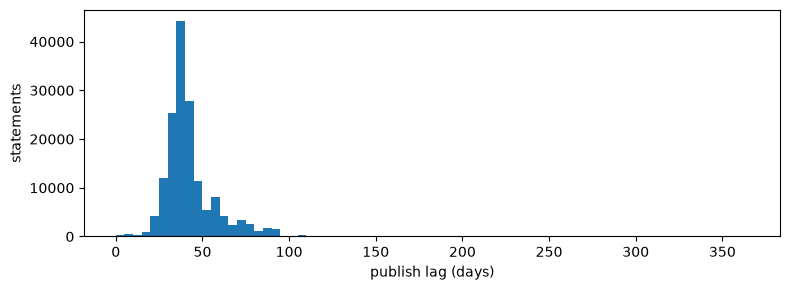

In [8]:
lags = con.execute("""
    SELECT date_diff('day', "Report Date", "Publish Date") AS lag
    FROM income
    WHERE IsRestated = false AND "Publish Date" IS NOT NULL AND Period = 'Q'
      AND date_diff('day', "Report Date", "Publish Date") BETWEEN 0 AND 365
""").df()
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lags['lag'], bins=73)
ax.set_xlabel('publish lag (days)')
ax.set_ylabel('statements')
plt.tight_layout()
plt.show()

### Placeholder hunt: most frequent Publish Dates

In [9]:
show_df(con.execute("""
    SELECT "Publish Date", count(*) AS Rows_
    FROM income GROUP BY 1 ORDER BY Rows_ DESC LIMIT 10
""").df())

,Publish Date,Rows_
0,2026-02-26,900
1,2021-02-25,877
2,2025-02-27,873
3,2022-03-01,858
4,2022-02-24,850
5,2021-02-26,821
6,2016-02-29,820
7,2019-02-28,812
8,2025-08-07,794
9,2024-08-08,777


**Verdict:** `Publish Date` is fully populated (0% null) and essentially never equals `Report
Date` (0.02% of rows), so it is not a copy-filled placeholder: a trustworthy as-of date. Lag is
short and stable across the whole 1999-2026 span (quarterly: median 39 days, p90 72 days; annual:
median 63 days, p90 400 days, the long annual tail likely holding-company/foreign filers). PIT
joins should use `Publish Date` directly; where a conservative default is needed before it is
known, `Report Date` plus 72 days (Q) or 400 days (A) covers the 90th percentile. About 600 rows
per period (well under 0.5%) have `Publish Date` before `Report Date`, a genuine data quirk worth
logging in `9999_data_quirks.ipynb` and excluding or clipping to 0 in any PIT lag calculation.

## 3. Original vs restated

### Key uniqueness per side

In [10]:
for table in ['income', 'balance', 'cashflow']:
    show_df(con.execute(f"""
        SELECT ? AS Statement, IsRestated,
               count(*) - count(DISTINCT (Ticker, Market, Period, "Fiscal Year", "Fiscal Period"))
                   AS DuplicateKeys
        FROM {table} GROUP BY IsRestated ORDER BY IsRestated
    """, [table]).df())

,Statement,IsRestated,DuplicateKeys
0,income,False,0
1,income,True,0


,Statement,IsRestated,DuplicateKeys
0,balance,False,0
1,balance,True,0


,Statement,IsRestated,DuplicateKeys
0,cashflow,False,0
1,cashflow,True,0


### Pairing original rows to their restated counterpart (income)

In [11]:
KEY = 'Ticker, Market, Period, "Fiscal Year", "Fiscal Period"'
show_df(con.execute(f"""
    WITH o AS (SELECT * FROM income WHERE IsRestated = false),
         r AS (SELECT * FROM income WHERE IsRestated = true)
    SELECT
        (SELECT count(*) FROM o JOIN r USING ({KEY})) AS pairs,
        (SELECT count(*) FROM o) AS original_rows,
        (SELECT count(*) FROM r) AS restated_rows
""").df())

,pairs,original_rows,restated_rows
0,"207,032","225,060","210,722"


### Share of pairs differing beyond the quality tolerance, key lines

In [12]:
LINES = [('income', 'Revenue'), ('income', 'Net Income'), ('balance', 'Total Assets'),
         ('cashflow', 'Net Cash from Operating Activities')]
for table, line in LINES:
    show_note(f'{table}.{line}')
    show_df(con.execute(f"""
        WITH o AS (SELECT * FROM {table} WHERE IsRestated = false),
             r AS (SELECT * FROM {table} WHERE IsRestated = true),
             j AS (SELECT o."{line}" AS ov, r."{line}" AS rv FROM o JOIN r USING ({KEY}))
        SELECT count(*) AS pairs,
               sum(CASE WHEN (ov IS NULL) <> (rv IS NULL) THEN 1 ELSE 0 END) AS one_side_null,
               sum(CASE WHEN ov IS NOT NULL AND rv IS NOT NULL
                             AND abs(ov - rv) > greatest(0.01 * abs(rv), 100000) THEN 1 ELSE 0 END) AS differing,
               round(median(CASE WHEN ov IS NOT NULL AND rv IS NOT NULL AND abs(ov - rv) > greatest(0.01 * abs(rv), 100000)
                                 THEN 100.0 * abs(ov - rv) / nullif(abs(rv), 0) END), 1) AS median_diff_pct,
               round(quantile_cont(CASE WHEN ov IS NOT NULL AND rv IS NOT NULL AND abs(ov - rv) > greatest(0.01 * abs(rv), 100000)
                                        THEN 100.0 * abs(ov - rv) / nullif(abs(rv), 0) END, 0.9), 1) AS p90_diff_pct
        FROM j
    """).df())

*income.Revenue*

,pairs,one_side_null,differing,median_diff_pct,p90_diff_pct
0,"207,032","1,215","13,489",15.9,201.6


*income.Net Income*

,pairs,one_side_null,differing,median_diff_pct,p90_diff_pct
0,"207,032",0,"12,175",32.2,281.1


*balance.Total Assets*

,pairs,one_side_null,differing,median_diff_pct,p90_diff_pct
0,"207,031",0,"4,726",10.4,358


*cashflow.Net Cash from Operating Activities*

,pairs,one_side_null,differing,median_diff_pct,p90_diff_pct
0,"207,035",23,"20,315",20,244.4


### Restatement timing: days from original `Publish Date` to `Restated Date` (income)

In [13]:
show_df(con.execute(f"""
    WITH o AS (SELECT * FROM income WHERE IsRestated = false),
         r AS (SELECT * FROM income WHERE IsRestated = true)
    SELECT count(*) AS pairs,
           median(date_diff('day', o."Publish Date", r."Restated Date")) AS p50,
           quantile_cont(date_diff('day', o."Publish Date", r."Restated Date"), 0.9) AS p90,
           sum(CASE WHEN r."Restated Date" < o."Publish Date" THEN 1 ELSE 0 END) AS restated_before_publish
    FROM o JOIN r USING ({KEY})
    WHERE o."Publish Date" IS NOT NULL AND r."Restated Date" IS NOT NULL
""").df())

,pairs,p50,p90,restated_before_publish
0,"207,032",365,730,"4,126"


**Verdict:** restatements are not cosmetic. Depending on the line, 2-10% of pairs differ
beyond tolerance (Total Assets 2.3%, Net Income 5.9%, Revenue 6.5%, operating cash flow 9.8%), and
when they differ the typical difference is large (median 10-32%, p90 above 200%). Restatements land
roughly a year after the original publish (p50 365 days). This confirms the PIT design must use
original (`IsRestated = false`) statements as-of `Publish Date`: using restated figures for a
historical date would leak knowledge unavailable at the time. Restated statements stay useful for
"best known figures today" research, not point-in-time decisions. About 2% of pairs have a
`Restated Date` before the original `Publish Date`, a timing quirk worth a quirks-log entry.

## 4. Column usability

### Fill rate per column, by period, per statement (shortlist at 60% quarterly fill)

In [14]:
ID_COLS = {'Ticker', 'SrcId', 'Src', 'Currency', 'Market', 'Period', 'IsRestated', 'Fiscal Year',
           'Fiscal Period', 'Report Date', 'Publish Date', 'Restated Date'}
FILL_THRESHOLD = 60.0
shortlists = {}

for table in ['income', 'balance', 'cashflow']:
    schema = con.execute(f'DESCRIBE {table}').df()
    value_cols = [row['column_name'] for _, row in schema.iterrows() if row['column_name'] not in ID_COLS]
    counts_sql = ', '.join(f'count("{c}") AS "{c}"' for c in value_cols)
    wide = con.execute(f'SELECT Period, count(*) AS _rows, {counts_sql} FROM {table} GROUP BY Period').df()
    long = wide.melt(id_vars=['Period', '_rows'], var_name='column', value_name='nonnull')
    long['fill_pct'] = round(100.0 * long['nonnull'] / long['_rows'], 1)
    fill = long.pivot(index='column', columns='Period', values='fill_pct').sort_values('Q', ascending=False)
    show_note(f'{table}: {len(value_cols)} value columns')
    show_df(fill)
    shortlists[table] = fill[fill['Q'] >= FILL_THRESHOLD].index.tolist()
    show_note(f'shortlist (Q fill >= {FILL_THRESHOLD}%): {len(shortlists[table])} columns')
    print(shortlists[table])

*income: 60 value columns*

Period,A,Q
column,,
Income (Loss) Incl. Minority Interest,100,100
Income (Loss) from Continuing Operations,100,100
Net Income,100,100
Net Income (Common),100,100
"Pretax Income (Loss), Adj.",100,100
Operating Income (Loss),100,100
Pretax Income (Loss),100,100
Operating Expenses,99.7,99.8
Shares (Basic),98.9,99.3


*shortlist (Q fill >= 60.0%): 18 columns*

['Income (Loss) Incl. Minority Interest', 'Income (Loss) from Continuing Operations', 'Net Income', 'Net Income (Common)', 'Pretax Income (Loss), Adj.', 'Operating Income (Loss)', 'Pretax Income (Loss)', 'Operating Expenses', 'Shares (Basic)', 'Shares (Diluted)', 'Non-Operating Income (Loss)', 'Selling, General & Administrative', 'Revenue', 'Interest Expense, Net', 'Income Tax (Expense) Benefit, Net', 'Cost of Revenue', 'Gross Profit', 'Other Non-Operating Income (Loss)']


*balance: 87 value columns*

...

['Total Liabilities', 'Total Assets', 'Total Equity', 'Total Current Assets', 'Total Liabilities & Equity', 'Total Current Liabilities', 'Cash, Cash Equivalents & Short Term Investments', 'Payables & Accruals', 'Total Noncurrent Assets', 'Cash & Cash Equivalents', 'Equity Before Minority Interest', 'Shares (Basic)', 'Shares (Diluted)', 'Share Capital & Additional Paid-In Capital', 'Other Short Term Assets', 'Other Long Term Assets', 'Total Noncurrent Liabilities', 'Property, Plant & Equipment, Net', 'Retained Earnings', 'Misc. Long Term Assets', 'Accounts Payable', 'Other Long Term Liabilities', 'Misc. Long Term Liabilities', 'Accounts & Notes Receivable', 'Other Payables & Accruals', 'Accounts Receivable, Net', 'Other Equity', 'Other Short Term Liabilities', 'Long Term Debt', 'Prepaid Expenses', 'Misc. Short Term Liabilities', 'Goodwill', 'Inventories']


*cashflow: 54 value columns*

Period,A,Q
column,,
Net Cash Before Disc. Operations and FX,100,100
Net Cash Before FX,100,100
Net Change in Cash,100,100
Net Cash from Operating Activities,100,100
Shares (Basic),98.9,99.3
Shares (Diluted),98.4,99.1
Net Income/Starting Line,99.2,98.6
Change in Working Capital,99.4,98.5
Net Cash from Financing Activities,98.9,98.4


*shortlist (Q fill >= 60.0%): 18 columns*

['Net Cash Before Disc. Operations and FX', 'Net Cash Before FX', 'Net Change in Cash', 'Net Cash from Operating Activities', 'Shares (Basic)', 'Shares (Diluted)', 'Net Income/Starting Line', 'Change in Working Capital', 'Net Cash from Financing Activities', 'Non-Cash Items', 'Net Cash from Investing Activities', 'Depreciation & Amortization', 'Change in Fixed Assets & Intangibles', 'Cash from (Repurchase of) Equity', 'Cash from (Repayment of) Debt', 'Other Financing Activities', 'Increase in Capital Stock', 'Other Investing Activities']


### VARCHAR-typed value columns: are they numeric under the hood?

In [15]:
for table in ['income', 'balance', 'cashflow']:
    schema = con.execute(f'DESCRIBE {table}').df()
    varchar_cols = [row['column_name'] for _, row in schema.iterrows()
                    if row['column_type'] == 'VARCHAR' and row['column_name'] not in ID_COLS]
    for c in varchar_cols:
        df = con.execute(f'SELECT count("{c}") AS nonnull, count(TRY_CAST("{c}" AS DOUBLE)) AS castable FROM {table}').df()
        show_note(f'{table}."{c}": {df.iloc[0].to_dict()}')

*income."Acquired In-Process R&D": {'nonnull': 63, 'castable': 63}*

*income."Disposal of Assets": {'nonnull': 150, 'castable': 150}*

*income."Asset Write-Down": {'nonnull': 91, 'castable': 91}*

*income."Legal Settlement": {'nonnull': 202, 'castable': 202}*

*income."Sale of Investments & Unrealized Investments": {'nonnull': 163, 'castable': 163}*

*income."Insurance Settlement": {'nonnull': 6, 'castable': 6}*

*income."Tax Allowance/Credit": {'nonnull': 9, 'castable': 9}*

*balance."Unbilled Revenues": {'nonnull': 165, 'castable': 165}*

### Shares (Basic / Diluted) fill rate by fiscal year (income, original, quarterly)

In [16]:
show_df(con.execute("""
    SELECT "Fiscal Year" AS fy, count(*) AS Rows_,
           round(100.0 * count("Shares (Basic)") / count(*), 1) AS BasicPct,
           round(100.0 * count("Shares (Diluted)") / count(*), 1) AS DilutedPct
    FROM income
    WHERE IsRestated = false AND Period = 'Q' AND "Fiscal Year" BETWEEN 1999 AND 2026
    GROUP BY fy ORDER BY fy
""").df())

,fy,Rows_,BasicPct,DilutedPct
0,"1,999",35,100,100
1,"2,000",152,100,100
2,"2,001",534,99.4,99.4
3,"2,002","1,093",99.6,99.6
4,"2,003","1,615",99.6,99.8
5,"2,004","2,036",99.6,99.8
6,"2,005","2,434",99.5,99.7
7,"2,006","2,873",99.5,99.6
8,"2,007","3,318",99.4,99.5
9,"2,008","3,657",99.5,99.6


**Verdict:** the usable feature palette is each statement's shortlist (income 18, balance 33,
cashflow 18 columns): headline totals and subtotals, not the long tail of abnormal or one-off
detail lines, which are real but too sparse for general cross-sectional use. The VARCHAR-typed
columns (7 in income, 1 in balance) are a storage artifact of near-total sparsity, not a
data-quality problem: they cast cleanly to DOUBLE wherever populated, so `TRY_CAST` is safe if a
future feature ever needs them. Shares coverage stays at or above 98.7% across the entire
1999-2026 span, so per-share ratios need no era caveat.

## Decisions

- **Statement variant:** use original (`IsRestated = false`) statements for PIT features.
  Restated statements are for research questions accepting look-ahead, not point-in-time ones.
- **As-of rule:** `Publish Date` is the knowledge date; it is always populated and reliable.
- **Fallback rule:** if a consumer needs a date before `Publish Date` is confirmed, use
  `Report Date + 72 days` (quarterly) or `Report Date + 400 days` (annual); these cover the
  90th percentile of the observed lag.
- **Universe:** restrict PIT joins to the roughly 3,100 tickers present in both `prices` and
  `income`; the rest lack one side of the join.
- **Column palette:** start the ratio/feature set from each statement's fill-rate shortlist
  (income 18, balance 33, cashflow 18 columns); treat sparser lines as optional, coalesced to 0
  only where an identity check already establishes that convention.
- **Quirk candidates for `9999_data_quirks.ipynb`:** rows with `Publish Date` before
  `Report Date` (about 600 per period); pairs with `Restated Date` before the original
  `Publish Date` (about 2%); the fundamentals-only vs price-only ticker split (possible symbol
  mismatch, not yet investigated).